In [1]:
import time
import torch
import os
import IPython.display as display

if not hasattr(display, "set_matplotlib_formats"):
    # no-op fallback (or you can force retina/png instead)
    def set_matplotlib_formats(*args, **kwargs):
        return None
    display.set_matplotlib_formats = set_matplotlib_formats

from d2l.torch import Animator

from net import Net
from utils import load_val_dataset
from faco import MFACO_TSP

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
PRETRAINED_DIR = PROJECT_ROOT / "../pretrained"

# Optional wandb logging (lazy import to avoid hangs at import-time)
USE_WANDB = True
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "claco")
WANDB_ENTITY = os.environ.get("WANDB_ENTITY") or None
WANDB_MODE = os.environ.get("WANDB_MODE", "online")  # set to "offline" to avoid network
wandb = None

def _wandb_init(config: dict, name: str | None = None):
    """Init a fresh wandb run for each train() call.

    In notebooks it's common to re-run the train cell; reusing the same wandb run
    causes non-monotonic step warnings when we log with an explicit `step=`.
    """
    global wandb, USE_WANDB
    if not USE_WANDB:
        return None
    if wandb is None:
        try:
            import wandb as _wandb
            wandb = _wandb
        except Exception as e:
            USE_WANDB = False
            print("wandb disabled (import failed):", e)
            return None
    if wandb.run is not None:
        # Start a new run to avoid step going backwards on re-runs.
        try:
            wandb.finish()
        except Exception:
            pass
    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        config=config,
        name=name,
        mode=WANDB_MODE,
    )

torch.manual_seed(1234)

lr = 1e-4
H=10
mini_H=100
rho = 0.5
min_new_edges = 16
disable_heuristic = False
use_local_search = True
smooth_mmas = True
extend_ls = True
normalize_heuristic = True
no_logit_net = False
no_dynamic_feats = False
k_sparse = 32
n_ants = 100
steps_per_epoch = 32
epochs = 10

device = 'cuda:0'

# Import your compiled extension (needed for get_max_threads print below)
try:
    import faco_tsp
except Exception as e:
    faco_tsp = None
    print("Warning: could not import faco_tsp:", e)

if faco_tsp is not None:
    print("faco_tsp imported. OpenMP max threads:", faco_tsp.get_max_threads())

faco_tsp imported. OpenMP max threads: 10


In [ ]:
# Import training logic from train.py (keep notebook focused on experiments/plots)
from types import SimpleNamespace
import train as train_mod
from tqdm.notebook import tqdm as notebook_tqdm
from functools import partial

# Patch the tqdm symbol used inside train.py
train_mod.tqdm = partial(notebook_tqdm, disable=True)


# Re-export helpers if you still want to inspect/DEBUG them in notebook
_popcount_i64 = train_mod._popcount_i64
replay_logp_from_cpp_batch_trace = train_mod.replay_logp_from_cpp_batch_trace
train_instance = train_mod.train_instance
train_epoch_core = train_mod.train_epoch
validation_core = train_mod.validation


def _make_args(n_node, k_sparse, n_ants, steps_per_epoch, *, H, mini_H, device,
              rho=0.1, min_new_edges=8,
              disable_heuristic=True,
              use_local_search=True,
              smooth_mmas=False,
              extend_ls=False,
              normalized_heuristic=False,
              debug=False,
              use_wandb=False,
              no_logit_net=False,
              baseline='none', baseline_runs=1, baseline_time_limit=10.0):
    """Create a train.py-compatible args namespace from notebook globals."""
    return SimpleNamespace(
        # problem / graph
        n_node=int(n_node),
        k_sparse=int(k_sparse),
        n_ants=int(n_ants),
        steps_per_epoch=int(steps_per_epoch),
        epochs=None,
        lr=lr,
        seed=1234,
        device=str(device),

        # aco
        rho=float(rho),
        min_new_edges=int(min_new_edges),
        H=int(H),
        mini_H=int(mini_H),
        disable_heuristic=bool(disable_heuristic),
        no_local_search=not bool(use_local_search),
        no_smooth_mmas=not bool(smooth_mmas),
        extend_ls=bool(extend_ls),
        no_normalized_heuristic=not bool(normalized_heuristic),
        debug=bool(debug),
        no_logit_net=bool(no_logit_net),

        # logging
        no_wandb=not bool(use_wandb),
        wandb_project=WANDB_PROJECT,
        wandb_entity=WANDB_ENTITY,
        save_dir=str(PRETRAINED_DIR / 'tsp'),
        no_dynamic_feats=False,

        # baseline (validation)
        baseline=str(baseline),
        baseline_runs=int(baseline_runs),
        baseline_time_limit=float(baseline_time_limit),
    )


@torch.no_grad()
def validation(n_ants, epoch, net, val_dataset, k_sparse, animator, dynamic, args, baseline_values=None):
    """Notebook wrapper around train.py validation (keeps the old Animator plotting style)."""
    avg_last, avg_best, _gap = validation_core(
        args=args,
        epoch=epoch,
        net=net,
        val_dataset=val_dataset,
        dynamic=dynamic,
        baseline_values=baseline_values,
    )
    if animator is not None:
        animator.add(epoch + 1, (avg_last, avg_best))
    return avg_last, avg_best


def train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, dynamic,
          *,
          H=H,
          mini_H=mini_H,
          rho=rho,
          min_new_edges=min_new_edges,
          disable_heuristic=disable_heuristic,
          use_local_search=use_local_search,
          smooth_mmas=smooth_mmas,
          extend_ls=extend_ls,
          normalized_heuristic=normalize_heuristic,
          debug=False,
          use_wandb=USE_WANDB,
          no_logit_net=False,
          baseline='none',
          baseline_runs=1,
          baseline_time_limit=10.0,
          baseline_values=None,
          ):

    args = _make_args(
        n_node=n_node,
        k_sparse=k_sparse,
        n_ants=n_ants,
        steps_per_epoch=steps_per_epoch,
        H=H,
        mini_H=mini_H,
        device=device,
        rho=rho,
        min_new_edges=min_new_edges,
        disable_heuristic=disable_heuristic,
        use_local_search=use_local_search,
        smooth_mmas=smooth_mmas,
        extend_ls=extend_ls,
        normalized_heuristic=normalized_heuristic,
        debug=debug,
        use_wandb=use_wandb,
        no_logit_net=no_logit_net,
        baseline=baseline,
        baseline_runs=baseline_runs,
        baseline_time_limit=baseline_time_limit,
    )

    # (Optional) wandb init: keep the notebook helper, but make train.py see the same module
    run = None
    if use_wandb:
        run = _wandb_init(config=vars(args), name=f"tsp{n_node}")
        # make sure train.py logs to the same wandb module
        try:
            import wandb as _wb
            train_mod.wandb = _wb
            args.no_wandb = False
        except Exception as e:
            print('wandb disabled (import failed):', e)
            args.no_wandb = True

    net = Net(logit_net=not no_logit_net).to(device)
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs, eta_min=lr * 0.1)

    val_list = load_val_dataset(n_node, device)
    animator = Animator(xlabel='epoch', xlim=[0, epochs], legend=["Avg. sample obj.", "Best ACO obj."])

    avg_last, avg_aco_best = validation(n_ants, -1, net, val_list, k_sparse, animator, dynamic, args, baseline_values=baseline_values)
    val_results = [(avg_last, avg_aco_best)]

    global_step = 0
    sum_time = 0
    best_val = float('inf')

    for epoch in range(0, epochs):
        start = time.time()
        global_step, _train_avg_cost = train_epoch_core(args, epoch, net, optimizer, global_step, dynamic=dynamic)
        scheduler.step()
        sum_time += time.time() - start

        avg_last, avg_aco_best = validation(n_ants, epoch, net, val_list, k_sparse, animator, dynamic, args, baseline_values=baseline_values)
        val_results.append((avg_last, avg_aco_best))

        if avg_aco_best < best_val:
            best_val = avg_aco_best
            os.makedirs(PRETRAINED_DIR / 'tsp', exist_ok=True)
            torch.save(net.state_dict(), f"{PRETRAINED_DIR}/tsp/tsp{n_node}.pt")

    print('total training duration:', sum_time)

    for epoch in range(-1, epochs):
        print(f'epoch {epoch}:', val_results[epoch + 1])

    if use_wandb and run is not None:
        try:
            import wandb as _wb
            _wb.finish()
        except Exception:
            pass

    # return net, val_results


Learn heuristic for TSP100: 

wandb: updating run metadata


total training duration: 965.789059638977
epoch -1: (8.373904023319483, 7.819905765354633)
epoch 0: (8.282044626772404, 7.820544950664043)
epoch 1: (8.042941641062498, 7.821039255708456)
epoch 2: (7.853407438844442, 7.822707433253527)
epoch 3: (7.828439112752676, 7.824869379401207)
epoch 4: (7.825626946985722, 7.82444291934371)
epoch 5: (7.824495658278465, 7.823279749602079)
epoch 6: (7.823139313608408, 7.822579901665449)
epoch 7: (7.825660113245249, 7.825092826038599)
epoch 8: (7.8252981044352055, 7.824958432465792)
epoch 9: (7.82435679808259, 7.823801811784506)


wandb: uploading wandb-summary.json


wandb: uploading history steps 319-319, summary


wandb: 
wandb: Run history:
wandb:  train/avg_cost ▆▇▇▆▆██▅▆▆▅▆▅▇▆▄▃▃▃▅▃▄▄▃▅▃▂▃▂▄▂▄▃▂▄▁▃▃▃▄
wandb: train/best_cost ▄▅▆▇▄▅▅▅▆▇▆▄▆▄▃▆▄▇▁▅▂▃█▄▅▁▃█▆▆▆▆▅▄▆▃▃▅▆▆
wandb:     train/epoch ▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇██████
wandb: 
wandb: Run summary:
wandb:  train/avg_cost 7.49593
wandb: train/best_cost 7.49593
wandb:     train/epoch 9
wandb: 


wandb: 🚀 View run tsp100 at: https://wandb.ai/shoraaa-vnu/claco/runs/f3n9beue
wandb: ⭐️ View project at: https://wandb.ai/shoraaa-vnu/claco
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260118_145252-f3n9beue/logs


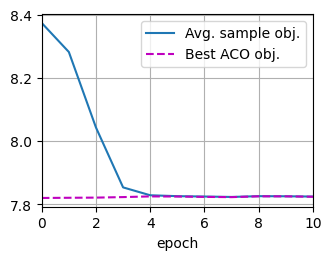

In [3]:

n_node = 100
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
min_new_edges = 16

train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

Learn heuristic for TSP500: 

In [4]:

# n_node = 200
# n_ants = 100
# k_sparse = 32
# steps_per_epoch = 32
# epochs = 10
# train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

wandb: updating run metadata


total training duration: 1117.6029505729675
epoch -1: (17.338120594620705, 16.764031395316124)
epoch 0: (17.32439674437046, 16.772832825779915)
epoch 1: (17.28178994357586, 16.784721940755844)
epoch 2: (17.17454755306244, 16.750075235962868)
epoch 3: (17.083563908934593, 16.7332054823637)
epoch 4: (16.990821167826653, 16.710822850465775)
epoch 5: (16.951159685850143, 16.70803327858448)
epoch 6: (16.92448179423809, 16.708502769470215)
epoch 7: (16.934638872742653, 16.719868272542953)
epoch 8: (16.934140220284462, 16.71238622069359)
epoch 9: (16.93043553829193, 16.717740014195442)


wandb: uploading wandb-summary.json


wandb: uploading history steps 319-319, summary


wandb: 
wandb: Run history:
wandb:  train/avg_cost ▇▅▇▇█▇▆▄▅▆▆▆▇█▃▄▄▄█▃▂▅▄▆█▆▃▂▅▃▆▃▂▆▆▆▄▁▄▂
wandb: train/best_cost ▅▅▆▇▆▅▆▆▄▃▅▇▄▄▇▆▂▇▁▃▅▁▄▆█▃▃▄▃▄▆▄▆▅▅▆▅▄▅▃
wandb:     train/epoch ▁▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▃▄▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████
wandb: 
wandb: Run summary:
wandb:  train/avg_cost 16.35982
wandb: train/best_cost 16.16289
wandb:     train/epoch 9
wandb: 


wandb: 🚀 View run tsp500 at: https://wandb.ai/shoraaa-vnu/claco/runs/4grlwge4
wandb: ⭐️ View project at: https://wandb.ai/shoraaa-vnu/claco
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260118_152354-4grlwge4/logs


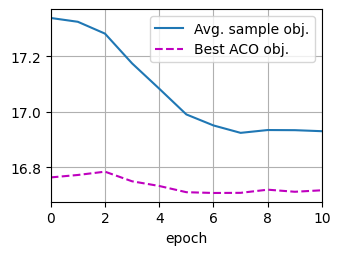

In [5]:
n_node = 500
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

wandb: updating run metadata


total training duration: 1220.2365083694458
epoch -1: (24.169127702713013, 23.687318325042725)
epoch 0: (24.153757214546204, 23.716288566589355)
epoch 1: (24.0893691778183, 23.714244842529297)
epoch 2: (24.017576575279236, 23.66345763206482)
epoch 3: (23.9028959274292, 23.564213037490845)
epoch 4: (23.791242957115173, 23.517255306243896)
epoch 5: (23.673920154571533, 23.43900239467621)
epoch 6: (23.60136914253235, 23.4031982421875)
epoch 7: (23.598949074745178, 23.400760769844055)
epoch 8: (23.57621729373932, 23.3916118144989)
epoch 9: (23.56531298160553, 23.387356400489807)


wandb: uploading wandb-summary.json


wandb: uploading history steps 319-319, summary


wandb: 
wandb: Run history:
wandb:  train/avg_cost ▅▆▅█▆▇▄█▅▇█▆█▇▆▅▃▅▄▆▃▄▅▄▆▃▃▃▃▃▁▃▄▃▃▅▂▂▂▂
wandb: train/best_cost █▄▅▄▂▅▆▇▅▅▄▆▆▂▄▃▃▆▆▅▅▅▃▇▆▇▅▅▅▁▄▂▂▃▄▃▃▃▁▃
wandb:     train/epoch ▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▆▆▆▆▆▆▆▆▆▇▇████
wandb: 
wandb: Run summary:
wandb:  train/avg_cost 24.07369
wandb: train/best_cost 23.84227
wandb:     train/epoch 9
wandb: 


wandb: 🚀 View run tsp1000 at: https://wandb.ai/shoraaa-vnu/claco/runs/wvsrvnod
wandb: ⭐️ View project at: https://wandb.ai/shoraaa-vnu/claco
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260118_160039-wvsrvnod/logs


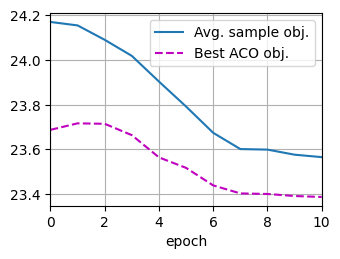

In [6]:
n_node = 1000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

In [7]:
# n_nod  , k_sparse, n_ants, steps_per_epoch, epochs, True)

wandb: updating run metadata


total training duration: 2302.521580219269
epoch -1: (53.15387845039368, 52.881240367889404)
epoch 0: (52.88466262817383, 52.68743109703064)
epoch 1: (52.74721550941467, 52.57914853096008)
epoch 2: (52.46666884422302, 52.324111461639404)
epoch 3: (52.14471936225891, 52.04115629196167)
epoch 4: (51.93043065071106, 51.85428524017334)
epoch 5: (51.86638069152832, 51.79502248764038)
epoch 6: (51.839107513427734, 51.770532846450806)
epoch 7: (51.80771732330322, 51.74625563621521)
epoch 8: (51.794023513793945, 51.73265504837036)
epoch 9: (51.79763650894165, 51.74078869819641)


wandb: uploading wandb-summary.json


wandb: uploading config.yaml


wandb: uploading history steps 319-319, summary


wandb: 
wandb: Run history:
wandb:  train/avg_cost ▇▆███▇▅▇▄▆▇▆▇▄▅▄▆▄▅▄▄▃▂▂▃▁▄▂▂▃▂▃▂▁▂▃▂▃▂▃
wandb: train/best_cost ▆▇█▅▇▇▇▄▇▇▄▅▆▄▄▅▅▃▄▄▅▄▅▅▃▅▄▃▃▃▄▁▃▂▃▄▃▃▃▄
wandb:     train/epoch ▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▇▇▇▇█████
wandb: 
wandb: Run summary:
wandb:  train/avg_cost 51.98143
wandb: train/best_cost 51.92671
wandb:     train/epoch 9
wandb: 


wandb: 🚀 View run tsp5000 at: https://wandb.ai/shoraaa-vnu/claco/runs/0u7n4ast
wandb: ⭐️ View project at: https://wandb.ai/shoraaa-vnu/claco
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260118_162432-0u7n4ast/logs


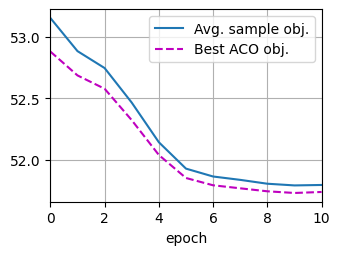

In [8]:
n_node = 5000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)